# Student Performance Classification using Machine Learning

## Objective

This notebook presents a complete machine learning pipeline to classify student performance using the **Student Performance Dataset**.

The project includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Model training
- Model evaluation
- Model comparison
- Final model selection

## Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,classification_report, roc_curve,confusion_matrix

#### Explanation

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

## Load the Dataset

In [56]:
df = pd.read_csv("student_performance_dataset.csv")

df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


#### Explanation

The dataset is loaded into a pandas DataFrame to prepare it for exploration and preprocessing.

Displaying the first few rows helps verify that the dataset has been loaded correctly.

## Dataset Size

In [57]:
df.shape

(1000, 12)

#### Explanation

The dataset shape is displayed to identify the number of observations (rows) and features (columns).

## Dataset Information

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            998 non-null    float64
 11  final_grade                 998 non-null    str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


#### Explanation

This step provides useful information about every feature, including:

- Data types
- Number of non-null values
- Memory usage

Understanding the dataset structure is important before preprocessing.

### The task is regression or classification
The selected dataset is the Student Performance Dataset.

The target variable is **final_grade**, which has two possible values:
- 0 = Pass
- 1 = Fail

Since the goal is to predict one of two categories rather than a continuous numerical value, this is a **classification** problem.

## Missing Values Analysis

In [59]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                2
final_grade                     2
dtype: int64

#### Explanation

The dataset is examined for missing values.

Detecting missing values early helps determine whether preprocessing is required before training machine learning models.

## Statistical Summary

In [60]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,998.000000
mean,500.500000,3.570700,85.092300,6.799500,69.671900,82.458818
std,288.819436,1.478559,9.270685,1.203527,12.640929,11.898448
min,1.000000,0.500000,54.800000,3.200000,31.300000,40.000000
25%,250.750000,2.600000,78.800000,5.900000,60.900000,75.400000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.100000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.275000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


#### Explanation

The statistical summary provides descriptive statistics for all numerical features, including:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

This helps understand the overall distribution of the data.

## Handling Missing Values

In [61]:
df.fillna(df.mode().iloc[0], inplace=True)



df.isnull().sum()

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

#### Explanation

Missing values are replaced using the most frequent value (Mode).

This preprocessing step ensures that the dataset contains no missing values before model training.

## Exploratory Data Analysis (EDA)

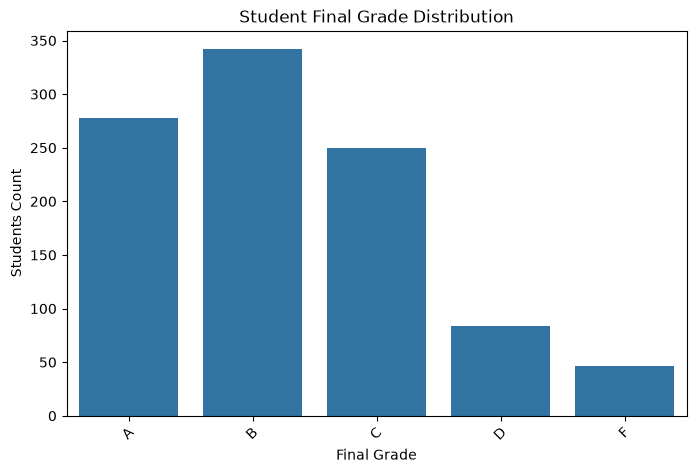

In [62]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='final_grade',
    order=sorted(df['final_grade'].unique())
)

plt.xlabel("Final Grade")
plt.ylabel("Students Count")
plt.title("Student Final Grade Distribution")
plt.xticks(rotation=45)

plt.show()

In [63]:
grade_class = ((df['final_grade'] == 'F') | (df['final_grade'] == 'D')).astype(int)

print("Class distribution:")
print(grade_class.value_counts())

print()

pass_rate = (grade_class == 0).mean() * 100
fail_rate = (grade_class == 1).mean() * 100

print(f"Passing students: {pass_rate:.1f}%")
print(f"Failing or Poor students: {fail_rate:.1f}%")





Class distribution:
final_grade
0    870
1    130
Name: count, dtype: int64

Passing students: 87.0%
Failing or Poor students: 13.0%


#### Explanation

The distribution of the target variable is visualized to understand whether the classes are balanced before training the models.

# Feature Engineering

In [64]:
x = df.drop(['final_grade','student_id'], axis=1)
y = grade_class

categorical_cols = x.select_dtypes(include=['object']).columns

x = pd.get_dummies(
    x,
    columns=categorical_cols,
    drop_first=True
)

print("X shape after encoding:", x.shape)
print("Columns:", x.columns.tolist())

X shape after encoding: (1000, 12)
Columns: ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score', 'gender_Male', 'parental_education_High School', 'parental_education_Masters', 'parental_education_PhD', 'internet_access_Yes', 'extracurricular_activities_Yes', 'part_time_job_Yes']


C:\Users\pc\AppData\Local\Temp\ipykernel_4848\423146445.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include=['object']).columns


#### Explanation

The target variable is separated from the input features.

Categorical variables are converted into numerical values using **One-Hot Encoding**, allowing machine learning algorithms to process them correctly.

## Three-Way Train/Validation/Test Split

The dataset is divided into three separate sets using a fixed `random_state`:

* **Training set (60%)** → Used to train the machine learning model.
* **Validation set (20%)** → Used to compare models and tune model settings.
* **Test set (20%)** → Kept separate and used only once for the final evaluation.

A fixed `random_state=42` is used to make the split reproducible.


In [65]:
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.25, random_state=42
)
print(f"Training set:  {x_train.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set:      {x_test.shape}")

Training set:  (600, 12)
Validation set: (200, 12)
Test set:      (200, 12)


#### Explanation

The dataset was successfully split into **60% training, 20% validation, and 20% testing data**.

The training set contains 600 samples, while the validation and test sets each contain 200 samples. The validation set will be used for model tuning, while the test set will remain untouched until the final evaluation.


## Random Forest Baseline

A Random Forest classifier is trained using the training set. Its performance is first evaluated on the validation set to establish a baseline before tuning the model.


In [66]:
forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(x_train, y_train)
forest_pred = forest_model.predict(x_val)
accuracy = accuracy_score(y_val, forest_pred)
f1 = f1_score(y_val, forest_pred, average='weighted')
report = classification_report(y_val, forest_pred)
print("Random Forest Classifier Performance on Validation Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print(report)

Random Forest Classifier Performance on Validation Set:
Accuracy: 1.0000
F1-score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       173
           1       1.00      1.00      1.00        27

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



#### Explanation

The Random Forest model is trained only on the training data and evaluated on the validation set.

The validation results provide a reference point before changing the model's hyperparameters.


## Random Forest Hyperparameter Tuning

The `n_estimators` hyperparameter is tuned using the validation set only.

Several values are tested, and the value that produces the highest validation accuracy is selected as the final setting. The test set is not used during this process.


In [67]:
n_estimators_values = [10, 50, 100, 200]
best_n_estimators = None
best_accuracy = 0
for n in n_estimators_values:
    forest=RandomForestClassifier(n_estimators=n, random_state=42)
    forest.fit(x_train, y_train)
    forest_pred = forest.predict(x_val)
    accuracy = accuracy_score(y_val, forest_pred)
    f1 = f1_score(y_val, forest_pred)
    print(f"Random Forest with n_estimators={n}:")
    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_n_estimators = n
print(f"Best n_estimators: {best_n_estimators}, Best Accuracy: {best_accuracy}")

Random Forest with n_estimators=10:
Accuracy: 1.0
F1 Score: 1.0
Random Forest with n_estimators=50:
Accuracy: 1.0
F1 Score: 1.0
Random Forest with n_estimators=100:
Accuracy: 1.0
F1 Score: 1.0
Random Forest with n_estimators=200:
Accuracy: 1.0
F1 Score: 1.0
Best n_estimators: 10, Best Accuracy: 1.0


#### Explanation

Different values of `n_estimators` were compared using the validation set.

The best value was selected based on validation accuracy. This allows the model to be tuned without using information from the test set.


## Final Model Evaluation on the Test Set

After selecting the best `n_estimators` value using the validation set, the final Random Forest model is evaluated on the test set.

The test set has not been used for training or hyperparameter tuning. This evaluation is performed only once to obtain an unbiased estimate of the final model's performance.


In [68]:
final_model = RandomForestClassifier(n_estimators=best_n_estimators, random_state=42)
final_model.fit(x_train, y_train)

final_pred = final_model.predict(x_test)
final_accuracy = accuracy_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_report = classification_report(y_test, final_pred)

print("Final Random Forest Model Performance on Test Set:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"F1-score: {final_f1:.4f}")
print(final_report)

Final Random Forest Model Performance on Test Set:
Accuracy: 1.0000
F1-score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       173
           1       1.00      1.00      1.00        27

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



#### Explanation

The final Random Forest model achieved an accuracy of **1.00** and an F1-score of **1.00** on the test set.

Because the test set was kept separate during model selection and tuning, this result provides the final evaluation of the selected model.


## Extra Experiment: Logistic Regression

As an additional experiment, Logistic Regression is tested as an alternative classification model.

This experiment is included for comparison and is not required for the main three-way split task. The model is trained and its performance is checked using the validation set.


In [69]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(x_train, y_train)
logistic_pred = logistic_model.predict(x_val)
logistic_accuracy = accuracy_score(y_val, logistic_pred)
logistic_f1 = f1_score(y_val, logistic_pred)
logistic_report = classification_report(y_val, logistic_pred)

print("Logistic Regression Performance on Validation Set:")
print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"F1-score: {logistic_f1:.4f}")
print(logistic_report)

Logistic Regression Performance on Validation Set:
Accuracy: 1.0000
F1-score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       173
           1       1.00      1.00      1.00        27

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



#### Explanation

Logistic Regression was tested as an additional classification model.

Its validation performance is used to understand how it compares with the Random Forest model before selecting the final model.


## Extra Experiment: Logistic Regression Hyperparameter Tuning

The regularization parameter `C` is tuned using the validation set.

Several values of `C` are tested, and the value with the highest validation accuracy is selected. The test set is not used during this additional experiment.


In [70]:
c_values = [0.01, 0.1, 1, 10, 100]
best_c = None
best_accuracy_log = 0
for c in c_values:
    logistic_model = LogisticRegression(max_iter=1000, C=c, random_state=42)
    logistic_model.fit(x_train, y_train)
    logistic_pred = logistic_model.predict(x_val)
    accuracy = accuracy_score(y_val, logistic_pred)
    f1 = f1_score(y_val, logistic_pred)
    print(f"Logistic Regression with C={c}:")
    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    if accuracy > best_accuracy_log:
        best_accuracy_log = accuracy
        best_c = c

print(f"Best C value: {best_c}")
print(f"Best Validation Accuracy: {best_accuracy_log:.4f}")

Logistic Regression with C=0.01:
Accuracy: 0.98
F1 Score: 0.92
Logistic Regression with C=0.1:
Accuracy: 0.99
F1 Score: 0.9615384615384616
Logistic Regression with C=1:
Accuracy: 1.0
F1 Score: 1.0
Logistic Regression with C=10:
Accuracy: 0.995
F1 Score: 0.9811320754716981
Logistic Regression with C=100:
Accuracy: 0.995
F1 Score: 0.9811320754716981
Best C value: 1
Best Validation Accuracy: 1.0000


#### Explanation

The validation results show that **C = 1** gives the highest validation accuracy of **1.00**.

Therefore, `C = 1` is selected as the best setting for the Logistic Regression experiment.

___

## What Would Go Wrong If the Test Set Were Used for Tuning?

The test set should not be used for hyperparameter tuning or model selection.

If we repeatedly evaluated different models or hyperparameter values on the test set and selected the best one based on its test performance, the model would indirectly become adapted to the test data.

As a result, the final test score could be overly optimistic and would no longer provide an unbiased estimate of how well the model performs on unseen data.

The correct approach is to use the training set for model training, the validation set for tuning and model selection, and the test set only once for the final evaluation.
